# M7 — Hedge collateral and liquidity

A hedge can reduce exposure to final prices while requiring cash payments before the related customer revenue arrives. **Liquidity** means having cash available when obligations are due. This lesson follows interim hedge payments to find the largest funding requirement.

Read M2, M3 and Notebook 2 first. A **hypothetical** supplier expects to sell 7,200 GPU-hours in month 3. It takes the seller's side of a hedge at USD 5. That side gains when the reference price falls and pays when it rises.

Prices recorded in months 1, 2 and 3 are **USD 6, USD 7 and USD 5**. The final sale price matches the final reference price.

First use a futures-style agreement: settle price changes in cash along the way. Also set aside **USD 5,000 at the start**, called **initial margin**, and return it in month 3. Later price-change payments are separate.

These are teaching rules, not actual exchange requirements. We leave out the supplier's compute purchase costs to focus on cash needed for the hedge. We assume no hardware ownership or rights over equipment.

In [1]:
# Install the teaching package from GitHub when running in Google Colab.
# Local Jupyter uses the repository's existing environment.
import subprocess
import sys

if "google.colab" in sys.modules:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "liquid-compute[colab] @ git+https://github.com/zach189/education.git@main",
        ]
    )
    from google.colab import output

    output.enable_custom_widget_manager()

In [2]:
from IPython.display import display

from liquid_compute.cashflows import maximum_funding_requirement_usd
from liquid_compute.collateral_liquidity import (
    futures_variation_cash_flows,
    otc_collateral_transfers,
)
from liquid_compute.education import (
    explore_finance_series,
    plot_finance_series,
    show_finance_table,
)

hedge = dict(
    entry_usd_per_gpu_hour=5.0,
    marks_usd_per_gpu_hour=(6.0, 7.0, 5.0),
    hedge_gpu_hours=7_200,
    mark_months=(1, 2, 3),
    side="seller",
)
initial_margin = 5_000.0
physical_receipt_usd = 7_200 * 5
print("Short hedge; physical sale and final financial settlement at month 3.")

Short hedge; physical sale and final financial settlement at month 3.


## Follow each price change

For the seller's hedge, multiply covered hours by the old price minus the new price.

From USD 5 to USD 6, pay **USD 7,200**. From USD 6 to USD 7, pay another **USD 7,200**. From USD 7 back to USD 5, receive **USD 14,400**.

These payments for price changes are **variation settlements**. Together they add to zero, since the final price equals the starting price.

But before the money returns, **USD 19,400** has gone out: USD 5,000 set aside plus USD 14,400 paid. We need that cash even though the hedge finishes with no gain or loss.

[CME's cash-flow explanation](https://www.cmegroup.com/education/courses/introduction-to-base-metals/cash-flow-in-metals-futures-vs-forwards) describes futures variation payments. Actual daily moves can need more cash than our monthly snapshots show.

In [3]:
direct_variation = [7_200 * (5 - 6), 7_200 * (6 - 7), 7_200 * (7 - 5)]
direct_cash = [
    -initial_margin,
    direct_variation[0],
    direct_variation[1],
    direct_variation[2] + initial_margin,
]
show_finance_table(
    ["Direct calculation", "USD"],
    [
        ["Month 1 variation", direct_variation[0]],
        ["Month 2 variation", direct_variation[1]],
        ["Month 3 variation", direct_variation[2]],
        ["Total variation", sum(direct_variation)],
        ["Peak cash required", maximum_funding_requirement_usd(direct_cash)],
    ],
)

| Direct calculation | USD |
| --- | --- |
| Month 1 variation | -7,200.00 |
| Month 2 variation | -7,200.00 |
| Month 3 variation | 14,400.00 |
| Total variation | 0.00 |
| Peak cash required | 19,400.00 |

## Separate posted margin from hedge settlements

The **USD 5,000 margin** is returned money set aside as security. It is not a permanent cost. The **USD 14,400 variation paid** is actual hedge settlement cash, later offset by a receipt.

We reuse M2's settlement arithmetic to calculate each change. Do not add the full final forward payoff again: those price-change payments already account for the hedge's result.

Keep month 0 and every price-check date. In month 3, the USD 14,400 receipt and USD 5,000 margin return bring the hedge's running cash total back to zero.

In [4]:
futures = futures_variation_cash_flows(**hedge, initial_margin_usd=initial_margin)


def ledger(rows):
    show_finance_table(
        [
            "Month",
            "Derivative settlement USD",
            "Collateral transfer USD",
            "Restricted balance USD",
            "Net cash USD",
            "Cumulative USD",
        ],
        [
            [
                r.month_offset,
                r.derivative_settlement_usd,
                r.collateral_transfer_usd,
                r.restricted_balance_usd,
                r.net_cash_usd,
                r.cumulative_cash_usd,
            ]
            for r in rows
        ],
    )


ledger(futures)

| Month | Derivative settlement USD | Collateral transfer USD | Restricted balance USD | Net cash USD | Cumulative USD |
| --- | --- | --- | --- | --- | --- |
| 0.00 | 0.00 | -5,000.00 | 5,000.00 | -5,000.00 | -5,000.00 |
| 1.00 | -7,200.00 | 0.00 | 5,000.00 | -7,200.00 | -12,200.00 |
| 2.00 | -7,200.00 | 0.00 | 5,000.00 | -7,200.00 | -19,400.00 |
| 3.00 | 14,400.00 | 5,000.00 | 0.00 | 19,400.00 | 0.00 |

## Identify the peak funding requirement

The chart shows only hedge cash. The customer pays after the biggest cash shortage has already happened. A later sale cannot pay an earlier margin call unless money is available elsewhere.

The optional controls change the second price and initial margin. Entry and final prices stay fixed. The controls leave the baseline and experiments alone; editable inputs and the static chart remain available.

[CME's margin explanation](https://www.cmegroup.com/education/courses/understanding-the-benefits-of-futures/the-benefits-of-futures-margins) distinguishes this security money from buying the underlying asset. Our fixed USD 5,000 does not model changing margin requirements or additional calls to restore a required balance.

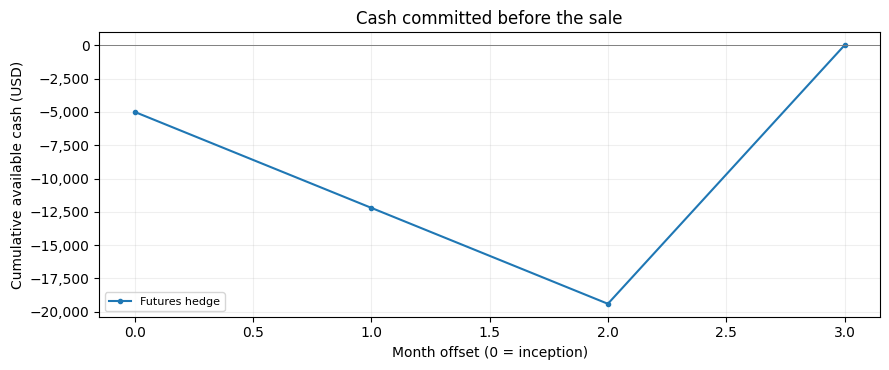

In [5]:
display(
    plot_finance_series(
        {"Futures hedge": [r.cumulative_cash_usd for r in futures]},
        title="Cash committed before the sale",
        ylabel="Cumulative available cash (USD)",
    )
)


def funding_explorer(values, baseline=hedge.copy()):
    from liquid_compute.cashflows import maximum_funding_requirement_usd
    from liquid_compute.collateral_liquidity import futures_variation_cash_flows

    rows = futures_variation_cash_flows(
        **(
            baseline
            | {"marks_usd_per_gpu_hour": (6, values["Second mark USD/GPU-hour"], 5)}
        ),
        initial_margin_usd=values["Initial margin USD"],
    )
    need = maximum_funding_requirement_usd([r.net_cash_usd for r in rows])
    return {
        f"Hedge cash; peak need {need:,.2f} USD": [r.cumulative_cash_usd for r in rows]
    }


explore_finance_series(
    {"Second mark USD/GPU-hour": 7.0, "Initial margin USD": 5_000.0},
    funding_explorer,
    title="Interim marks change funding",
);

The final cash total is zero, but the lowest point is **−USD 19,400**. That lowest point is the funding problem.

## Experiment 1 — Same final price, different funding need

Compare our USD 6/7/5 path with prices that stay at **USD 5/5/5**. Both end where they started. Both have zero total variation settlement.

The flat path still locks away USD 5,000, but requires no extra price-change payments. Looking only at the final price would miss that difference. We do not include interest on money borrowed to cover either path.

In [6]:
flat = futures_variation_cash_flows(
    **(hedge | {"marks_usd_per_gpu_hour": (5, 5, 5)}), initial_margin_usd=initial_margin
)
show_finance_table(
    ["Path", "Total variation USD", "Peak need USD"],
    [
        [
            name,
            sum(r.derivative_settlement_usd for r in rows),
            maximum_funding_requirement_usd([r.net_cash_usd for r in rows]),
        ]
        for name, rows in [("6/7/5", futures), ("5/5/5", flat)]
    ],
)

| Path | Total variation USD | Peak need USD |
| --- | --- | --- |
| 6/7/5 | 0.00 | 19,400.00 |
| 5/5/5 | 0.00 | 5,000.00 |

The biggest cash need falls from **USD 19,400 to USD 5,000** even though both hedges finish with the same result.

## Experiment 2 — Collateral under a private forward agreement

Now replace the futures-style arrangement with a private forward, also called **OTC**, for “over the counter.” This is a separate example.

Before the end, estimate its value to our seller as **7,200 × (USD 5 − current price)**. A negative value means the contract is currently unfavorable to the seller. This is a simple estimate without discounting.

Our seller posts cash security only for the part of that negative value beyond a **USD 5,000 threshold**. It receives no security from the other party when the value is positive. There is no interest on posted cash and no minimum transfer size.

Required posted balances are **USD 2,200, then USD 9,400**. Transfer only the change in the balance, not the whole balance again. At the end, return all posted cash and settle the forward once. These rules are hypothetical, not universal OTC practice.

In [7]:
otc = otc_collateral_transfers(**hedge, threshold_usd=5_000)
otc_zero = otc_collateral_transfers(**hedge, threshold_usd=0)
ledger(otc)
show_finance_table(
    ["OTC threshold USD", "Peak need USD", "Net collateral transfers USD"],
    [
        [
            threshold,
            maximum_funding_requirement_usd([r.net_cash_usd for r in rows]),
            sum(r.collateral_transfer_usd for r in rows),
        ]
        for threshold, rows in [(5_000, otc), (0, otc_zero)]
    ],
)

| Month | Derivative settlement USD | Collateral transfer USD | Restricted balance USD | Net cash USD | Cumulative USD |
| --- | --- | --- | --- | --- | --- |
| 0.00 | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 |
| 1.00 | 0.00 | -2,200.00 | 2,200.00 | -2,200.00 | -2,200.00 |
| 2.00 | 0.00 | -7,200.00 | 9,400.00 | -7,200.00 | -9,400.00 |
| 3.00 | -0.00 | 9,400.00 | 0.00 | 9,400.00 | 0.00 |

| OTC threshold USD | Peak need USD | Net collateral transfers USD |
| --- | --- | --- |
| 5,000.00 | 9,400.00 | 0.00 |
| 0.00 | 14,400.00 | 0.00 |

Allowing the USD 5,000 threshold reduces peak posted cash from **USD 14,400 to USD 9,400** compared with a zero threshold in this private-forward example.

In both cases, all posted cash comes back, so security transfers add to zero. The forward's separate final settlement is also zero here because the final price equals the starting price. A different final price would still require that settlement.

## Experiment 3 — The customer pays later

Keep the hedge dates unchanged, but move the **USD 36,000 customer payment from month 3 to month 5**. Extend the schedule to include it.

Only collection is late. Delivery, price, hedge end date and margin rules stay the same. As in Notebook 2, receipts and payments at the same time can offset each other.

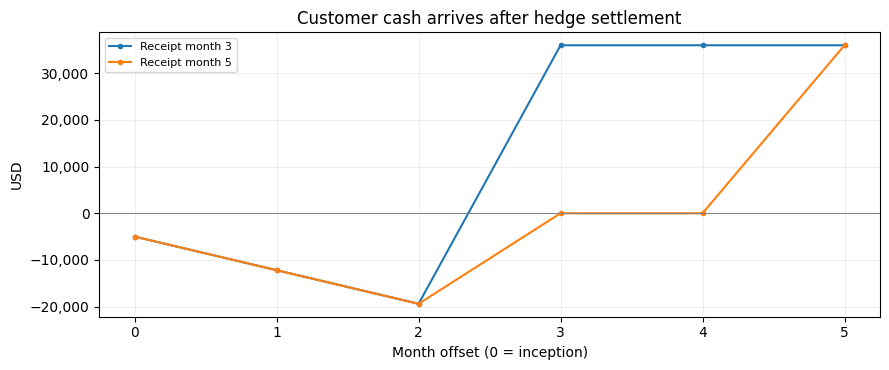

| Receipt month | Final cash USD | Peak need USD |
| --- | --- | --- |
| 3.00 | 36,000.00 | 19,400.00 |
| 5.00 | 36,000.00 | 19,400.00 |

In [8]:
from itertools import accumulate


def combined_cash(rows, receipt_month, amount=physical_receipt_usd):
    horizon = max(rows[-1].month_offset, receipt_month)
    cash = [0.0] * (horizon + 1)
    for row in rows:
        cash[row.month_offset] += row.net_cash_usd
    cash[receipt_month] += amount
    return cash


on_time = combined_cash(futures, 3)
delayed = combined_cash(futures, 5)

display(
    plot_finance_series(
        {
            "Receipt month 3": list(accumulate(on_time + [0, 0])),
            "Receipt month 5": list(accumulate(delayed)),
        },
        title="Customer cash arrives after hedge settlement",
    )
)
show_finance_table(
    ["Receipt month", "Final cash USD", "Peak need USD"],
    [
        [3, sum(on_time), maximum_funding_requirement_usd(on_time)],
        [5, sum(delayed), maximum_funding_requirement_usd(delayed)],
    ],
)

The later customer payment does **not** increase the **USD 19,400** peak cash need in this example. The hedge cash and margin already come back in month 3.

Different price paths or extra operating bills could change that result. A delay does not automatically mean a larger peak shortage.

Compare the complete cash paths when choosing protection. Similar final payoffs can need different amounts of money along the way.

These numbers cover the modeled hedge. A full business plan must also include compute purchases, running costs, loans and customer cash on their actual dates.

In [9]:
show_finance_table(
    ["Ledger", "Peak cash need USD"],
    [
        [name, maximum_funding_requirement_usd([r.net_cash_usd for r in rows])]
        for name, rows in [
            ("Futures rising path", futures),
            ("Futures flat path", flat),
            ("OTC threshold 5000", otc),
            ("OTC threshold zero", otc_zero),
        ]
    ],
)

| Ledger | Peak cash need USD |
| --- | --- |
| Futures rising path | 19,400.00 |
| Futures flat path | 5,000.00 |
| OTC threshold 5000 | 9,400.00 |
| OTC threshold zero | 14,400.00 |

## Next — Combine the transaction’s cash flows

The planned **C1 capstone** will combine financing and market-risk schedules. It is not implemented here. E1–E6 are optional unless the transaction uses their features.

Our monthly snapshots can miss larger daily or intraday cash needs. We leave out default, fees, funding interest and changing margin requirements.

This lesson tracks cash tied up by hedges. F6 instead limits loans backed by invoices. A lower cash need here does not prove the other party is safer or the real contract is better.